In [1]:
import kagglehub
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import prep_logs

logs = prep_logs.get_sleep_data()

sns.set_theme()

# Table verification

In [2]:
logs.head()

,Sleep Time,Wake Time,Duration,Notes
0,2025-10-16 05:21:00,2025-10-16 09:55:00,0 days 04:34:00,NaN
1,2025-10-17 01:10:00,2025-10-17 09:00:00,0 days 07:50:00,NaN
2,2025-10-18 00:35:00,2025-10-18 08:05:00,0 days 07:30:00,NaN
3,2025-10-18 23:00:00,2025-10-19 07:50:00,0 days 08:50:00,NaN
4,2025-10-19 23:00:00,2025-10-20 07:00:00,0 days 08:00:00,NaN


# Time variability

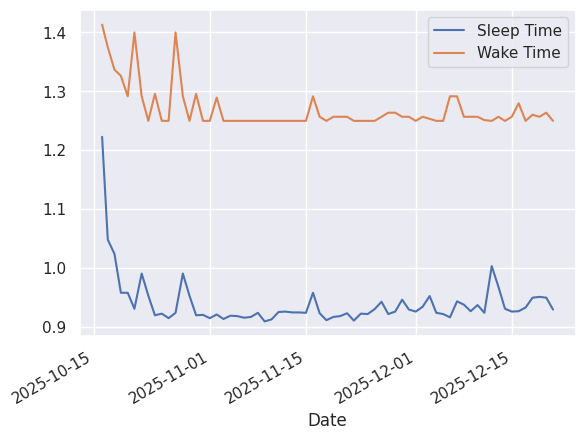

In [3]:
def normalize(s):
    s = s - pd.to_datetime(logs['Sleep Time'].dt.date)
    s = (s / pd.to_timedelta('1 days'))
    s = s.mask(s < 0.5, lambda v: v + 1)
    return s

normalized = logs[['Sleep Time', 'Wake Time']].apply(normalize).copy()
normalized['Date'] = logs['Sleep Time']
normalized.plot(x='Date')

del normalized

plt.show()

# Weekly mean durations

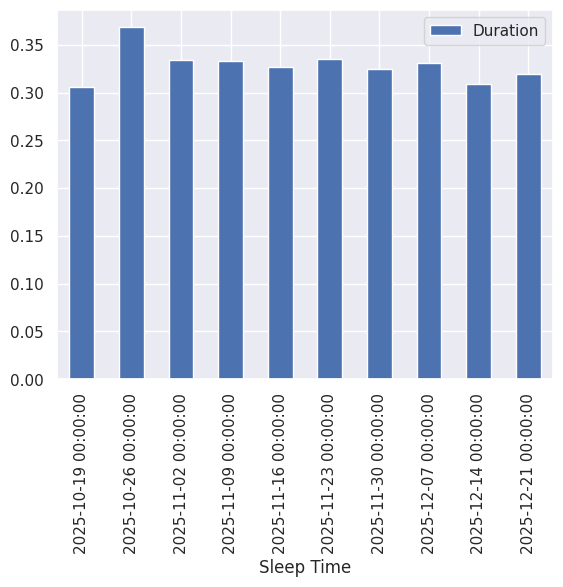

In [4]:
df = logs[['Sleep Time', 'Duration']].copy()
df['Duration'] = df['Duration'] / np.timedelta64(1, 'D')

(
    df
    .resample('W', on='Sleep Time')
    .mean()
    .plot(kind='bar')
)

del df

plt.show()

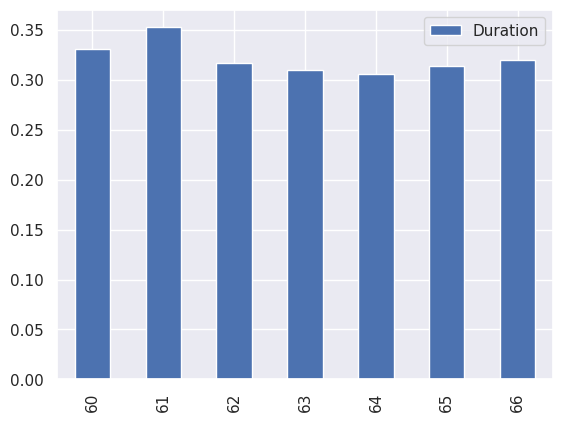

In [5]:
normalized = (logs['Duration'] / np.timedelta64(1, 'D'))

(
    normalized
    .to_frame()
    .tail(7)
    .plot(kind='bar')
)

del normalized

plt.show()

# Durations per weekday

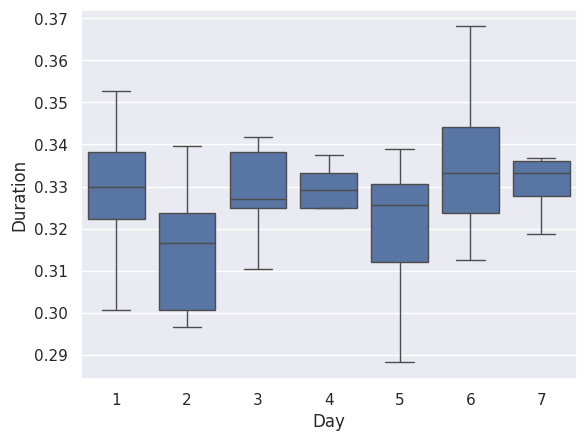

In [6]:
normalized = (logs['Duration'] / np.timedelta64(1, 'D')).to_frame()
normalized['Day'] = logs['Sleep Time'].dt.isocalendar().day

sns.boxplot(
    data=normalized,
    x='Day',
    y='Duration',
    showfliers=False,
)

del normalized

plt.show()